In [1]:
import numpy as np
import ot
from scipy.spatial.distance import cdist
from cellbridge.ot.fgw_multi import fused_gromov_wasserstein_multi
rng = np.random.default_rng(1)
import numpy as np 
import matplotlib as mpl
import matplotlib.pyplot as plt
import scienceplots
from matplotlib.lines import Line2D
from matplotlib.collections import LineCollection
import matplotlib.patches as mpatches
import matplotlib.patheffects as pe
from matplotlib.legend_handler import HandlerBase

def generate_data(means, sizes, variance=1):
    X = []
    y = []
    for i, mu in enumerate(means):
        X.append(rng.multivariate_normal(mu, np.eye(len(mu)) * variance, size=sizes[i]))
        y.append(np.full(sizes[i], i))
    return np.vstack(X), np.concatenate(y)

cons = 2
means_snapshot_1 = [[-cons, cons], [0,cons], [cons, cons]]
variance = 0.1
n_points = 35

translation_vectors = 2*np.array([[cons, -cons], [0, -cons], [-cons, -cons]])

X1, y1 = generate_data(means_snapshot_1, [n_points]*len(means_snapshot_1), variance)

X2 = np.empty_like(X1)
for i in range(len(X1)):
    X2[i] = X1[i] + translation_vectors[y1[i]]
y2 = y1

M = cdist(X1, X2)

def make_directed_D(labels):
    n = len(labels)
    D = np.zeros((n, n, 2), float)
    I0 = labels == 0
    I1 = labels == 1
    I2 = labels == 2

    D[np.ix_(I1, I0)] = [1.0, 0]
    D[np.ix_(I1, I2)] = [0.0, 1.0]

    
    return D

D1 = make_directed_D(y1)
D2 = make_directed_D(y2)




In [2]:

n, m = len(y1), len(y2)
p = np.full(n, 1.0/n)
q = np.full(m, 1.0/m)

from cellbridge.ot.cost import contributions_multi


T_gw, _ = fused_gromov_wasserstein_multi(M=np.zeros((n, m)), C1=D1, C2=D2, p=p, q=q, alpha=1.0, G0=np.outer(p, q), log=True)
T_ot = ot.emd(p, q, M)

Q = np.eye(2)
lin_gw, gw_gw   =  contributions_multi(M, D1, D2, T_gw, Q=Q)
lin_ot,  gw_ot  = contributions_multi(M, D1, D2, T_ot, Q=Q)

eps = np.finfo(float).eps
Delta_lin = max(abs(lin_ot - lin_gw), eps)   # how much the linear term actually moves across relevant T's
Delta_gw  = max(abs(gw_gw  - gw_ot),  eps)   # how much the GW variable part moves across relevant T's

M_scaled  = M  / Delta_lin
D1_scaled = D1 / np.sqrt(Delta_gw)
D2_scaled = D2 / np.sqrt(Delta_gw)



def fgw_path(Ms, C1s, C2s, p, q, alphas, G0=None, max_iter=1000, armijo=True):
    Ts=[]; logs=[]; contr=[]
    if G0 is None: 
        G0 = np.outer(p, q)
    for a in alphas:
        T, log = fused_gromov_wasserstein_multi(M=Ms, C1=C1s, C2=C2s, p=p, q=q, Q=np.eye(2),
                                                         alpha=a, G0=G0, armijo=armijo, log=True, max_iter=max_iter)
      
        Ts.append(T)
        logs.append(log)

        contr.append(contributions_multi(Ms, C1s, C2s, T, Q=Q))

        G0 = T
    return Ts, logs, np.asarray(contr)

alphas = np.linspace(1.0, 0.0, 11)  
Ts, logs, contr = fgw_path(M_scaled, D1_scaled, D2_scaled, p, q, alphas, G0=T_gw)



In [3]:
def plot_transport_three_panels(
    alpha_values,
    alphas,
    Ts,
    X1,
    X2,
    y1,
    y2,
    figsize=(7.2, 2.6),
    xlim=None,
    ylim=None,
    save_path=None,
    interaction_specs=None,
    centroid_star_size=210,
):
 

    plt.style.use("science")

    mpl.rcParams.update({
        "figure.dpi": 300,
        "savefig.dpi": 600,
        "font.size": 9,
        "axes.titlesize": 10,
        "axes.labelsize": 9,
        "xtick.labelsize": 8,
        "ytick.labelsize": 8,
        "legend.fontsize": 8,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.grid": False,
    })

    indices = [int(np.argmin(np.abs(alphas - a))) for a in alpha_values]
    actual_alphas = [float(alphas[idx]) for idx in indices]

    palette = {0: "#1f77b4", 1: "#ff7f0e", 2: "#2ca02c"}  # blue, orange, green
    snap1_style = dict(marker="o", s=18, alpha=0.85, linewidths=0)
    snap2_style = dict(marker="x", s=20, alpha=0.75, linewidths=0.8)

    if interaction_specs is None:
        interaction_specs = [
            ("Pathway A", 1, 0),
            ("Pathway B", 1, 2),
        ]

    pathway_color_cycle = ["#d62728", "#9467bd", "#8c564b", "#e377c2", "#17becf"]
    pathway_colors = {
        name: pathway_color_cycle[i % len(pathway_color_cycle)]
        for i, (name, _, _) in enumerate(interaction_specs)
    }

    y1 = np.asarray(y1)
    y2 = np.asarray(y2)
    unique_labels = sorted(set(np.unique(y1)).union(set(np.unique(y2))))

    centroids_1 = {
        lab: X1[y1 == lab].mean(axis=0)
        for lab in unique_labels
        if np.any(y1 == lab)
    }
    centroids_2 = {
        lab: X2[y2 == lab].mean(axis=0)
        for lab in unique_labels
        if np.any(y2 == lab)
    }

    fig, axes = plt.subplots(1, 3, sharex=True, sharey=True, figsize=figsize)

    for k, (ax, idx, a) in enumerate(zip(axes, indices, actual_alphas)):
        T = Ts[idx]

        ax.scatter(
            X1[:, 0],
            X1[:, 1],
            c=[palette.get(l, "#888888") for l in y1],
            **snap1_style,
            label="Snapshot 1",
        )
        ax.scatter(
            X2[:, 0],
            X2[:, 1],
            c=[palette.get(l, "#888888") for l in y2],
            **snap2_style,
            label="Snapshot 2",
        )

        segs, widths, alphas_ = [], [], []
        n1, n2 = T.shape
        ALPHA_MIN, ALPHA_MAX = 0.03, 0.18
        WIDTH_MIN, WIDTH_MAX = 0.15, 0.60

        for i in range(n1):
            row = T[i]
            m = row.max()
            if m <= 0:
                continue
            j = int(np.argmax(row))
            w = row[j] / m
            segs.append([(X1[i, 0], X1[i, 1]), (X2[j, 0], X2[j, 1])])
            widths.append(WIDTH_MIN + (WIDTH_MAX - WIDTH_MIN) * w)
            alphas_.append(ALPHA_MIN + (ALPHA_MAX - ALPHA_MIN) * w)

        gray = 0.25
        colors = [(gray, gray, gray, a_) for a_ in alphas_]
        lc = LineCollection(
            segs,
            linewidths=widths,
            colors=colors,
            capstyle="round",
            zorder=1,
            rasterized=True,
        )
        ax.add_collection(lc)

        if np.isclose(a, 0.0):
            for lab in unique_labels:
                c = palette.get(lab, "#888888")
                if lab in centroids_1:
                    p1 = centroids_1[lab]
                    ax.scatter(
                        p1[0],
                        p1[1],
                        marker="*",
                        s=centroid_star_size,
                        c=[c],
                        edgecolors="black",
                        linewidths=1.0,
                        zorder=5,
                    )
                if lab in centroids_2:
                    p2 = centroids_2[lab]
                    ax.scatter(
                        p2[0],
                        p2[1],
                        marker="*",
                        s=centroid_star_size,
                        c=[c],
                        edgecolors="black",
                        linewidths=1.0,
                        zorder=5,
                    )

            for g_idx, centroids_group in enumerate((centroids_1, centroids_2)):
                for p_idx, (path_label, src_lab, dst_lab) in enumerate(interaction_specs):
                    if (src_lab not in centroids_group) or (dst_lab not in centroids_group):
                        continue

                    start = centroids_group[src_lab]
                    end = centroids_group[dst_lab]
                    rad = 0.16 if (p_idx % 2 == 0) else -0.16

                    path_color = pathway_colors.get(path_label, "#333333")
                    ax.annotate(
                        "",
                        xy=(end[0], end[1]),
                        xytext=(start[0], start[1]),
                        arrowprops=dict(
                            arrowstyle="-|>",
                            mutation_scale=13,
                            color=path_color,
                            lw=2.0,
                            alpha=0.95,
                            connectionstyle=f"arc3,rad={rad}",
                        ),
                        zorder=4,
                    )

                    direction = end - start
                    norm = np.linalg.norm(direction)
                    if norm > 1e-12:
                        normal = np.array([-direction[1], direction[0]]) / norm
                    else:
                        normal = np.array([0.0, 0.0])

                    label_pos = 0.5 * (start + end)
                    label_pos = label_pos.copy()
                    if g_idx == 0:
                        label_pos[1] += 0.34
                    else:
                        label_pos[1] += 0.16

                    short_label = path_label.replace("Pathway", "").strip()
                    txt = ax.text(
                        label_pos[0],
                        label_pos[1],
                        short_label,
                        fontsize=10,
                        color="black",
                        ha="center",
                        va="center",
                        fontweight="bold",
                        zorder=6,
                    )
                    txt.set_path_effects([pe.withStroke(linewidth=2.0, foreground="white")])

        ax.collections[0].set_zorder(3)
        ax.collections[1].set_zorder(3)

        ax.set_title(rf"$\alpha={a:.1f}$", pad=4)
        ax.set_aspect("equal", adjustable="box")
        ax.set_xlim(*(xlim if xlim is not None else (-5, 5)))
        ax.set_ylim(*(ylim if ylim is not None else (-5, 5)))
        ax.tick_params(length=3, width=0.6)
        ax.text(
            0.02,
            0.98,
            f"({chr(97 + k)})",
            transform=ax.transAxes,
            ha="left",
            va="top",
            weight="bold",
        )

    # for ax in axes:
    #     ax.set_xlabel("Feature 1")
    # axes[0].set_ylabel("Feature 2")

    snap1_handle = Line2D([0], [0], marker="o", linestyle="None", markersize=6,
                          markerfacecolor="#888", markeredgecolor="#333", markeredgewidth=0.8,
                          label="Snapshot 1")
    snap2_handle = Line2D([0], [0], marker="x", linestyle="None", markersize=7,
                          color="#444", markeredgewidth=1.2, label="Snapshot 2")
    class Pathway:
        def __init__(self, c_from, c_to, c_path):
            self.c_from = c_from
            self.c_to = c_to
            self.c_path = c_path

    class HandlerPathway(HandlerBase):
        def create_artists(self, legend, orig_handle, xdescent, ydescent,
                           width, height, fontsize, trans):
            h = height * 0.70
            s = h
            y = ydescent + (height - s) / 2
            xL = xdescent
            xR = xdescent + width - s

            left_sq = mpatches.Rectangle((xL, y), s, s,
                                         facecolor=orig_handle.c_from, edgecolor="black",
                                         linewidth=1.0, transform=trans)
            right_sq = mpatches.Rectangle((xR, y), s, s,
                                          facecolor=orig_handle.c_to, edgecolor="black",
                                          linewidth=1.0, transform=trans)

            ax0 = xL + s + 0.06 * width
            ax1 = xR - 0.06 * width
            ay = y + s / 2
            arrow = mpatches.FancyArrowPatch((ax0, ay), (ax1, ay), arrowstyle="->",
                                             mutation_scale=fontsize * 1.2,
                                             linewidth=1.8, color=orig_handle.c_path, transform=trans)
            return [left_sq, arrow, right_sq]

    class TightMarkerHandler(HandlerBase):
        def create_artists(self, legend, orig_handle, xdescent, ydescent,
                           width, height, fontsize, trans):
            x = xdescent + 0.15 * height
            y = ydescent + 0.5 * height
            msize = orig_handle.get_markersize()
            artist = Line2D([x], [y],
                            marker=orig_handle.get_marker(),
                            markersize=msize,
                            markerfacecolor=orig_handle.get_markerfacecolor(),
                            markeredgecolor=orig_handle.get_markeredgecolor(),
                            markeredgewidth=orig_handle.get_markeredgewidth(),
                            linestyle="", color=orig_handle.get_color(), transform=trans)
            return [artist]

    handles = [snap1_handle, snap2_handle]
    labels = ["Snapshot 1", "Snapshot 2"]
    for path_label, src_lab, dst_lab in interaction_specs:
        handles.append(
            Pathway(
                palette.get(src_lab, "#888888"),
                palette.get(dst_lab, "#888888"),
                pathway_colors.get(path_label, "#444444"),
            )
        )
        labels.append(path_label)

    fig.subplots_adjust(bottom=0.44)
    fig.legend(
        fontsize=11,
        handles=handles,
        labels=labels,
        loc="lower center", 
        bbox_to_anchor=(0.5, -0.065),
        ncol=len(handles),
        frameon=False,
        markerfirst=False,
        handlelength=3,
        handletextpad=0.5,
        columnspacing=1.0,
        handler_map={
            Pathway: HandlerPathway(),
            Line2D: TightMarkerHandler(),
        },
    )

    fig.tight_layout(w_pad=0.8)

    if save_path:
        plt.savefig(save_path, bbox_inches="tight")

    return fig, axes











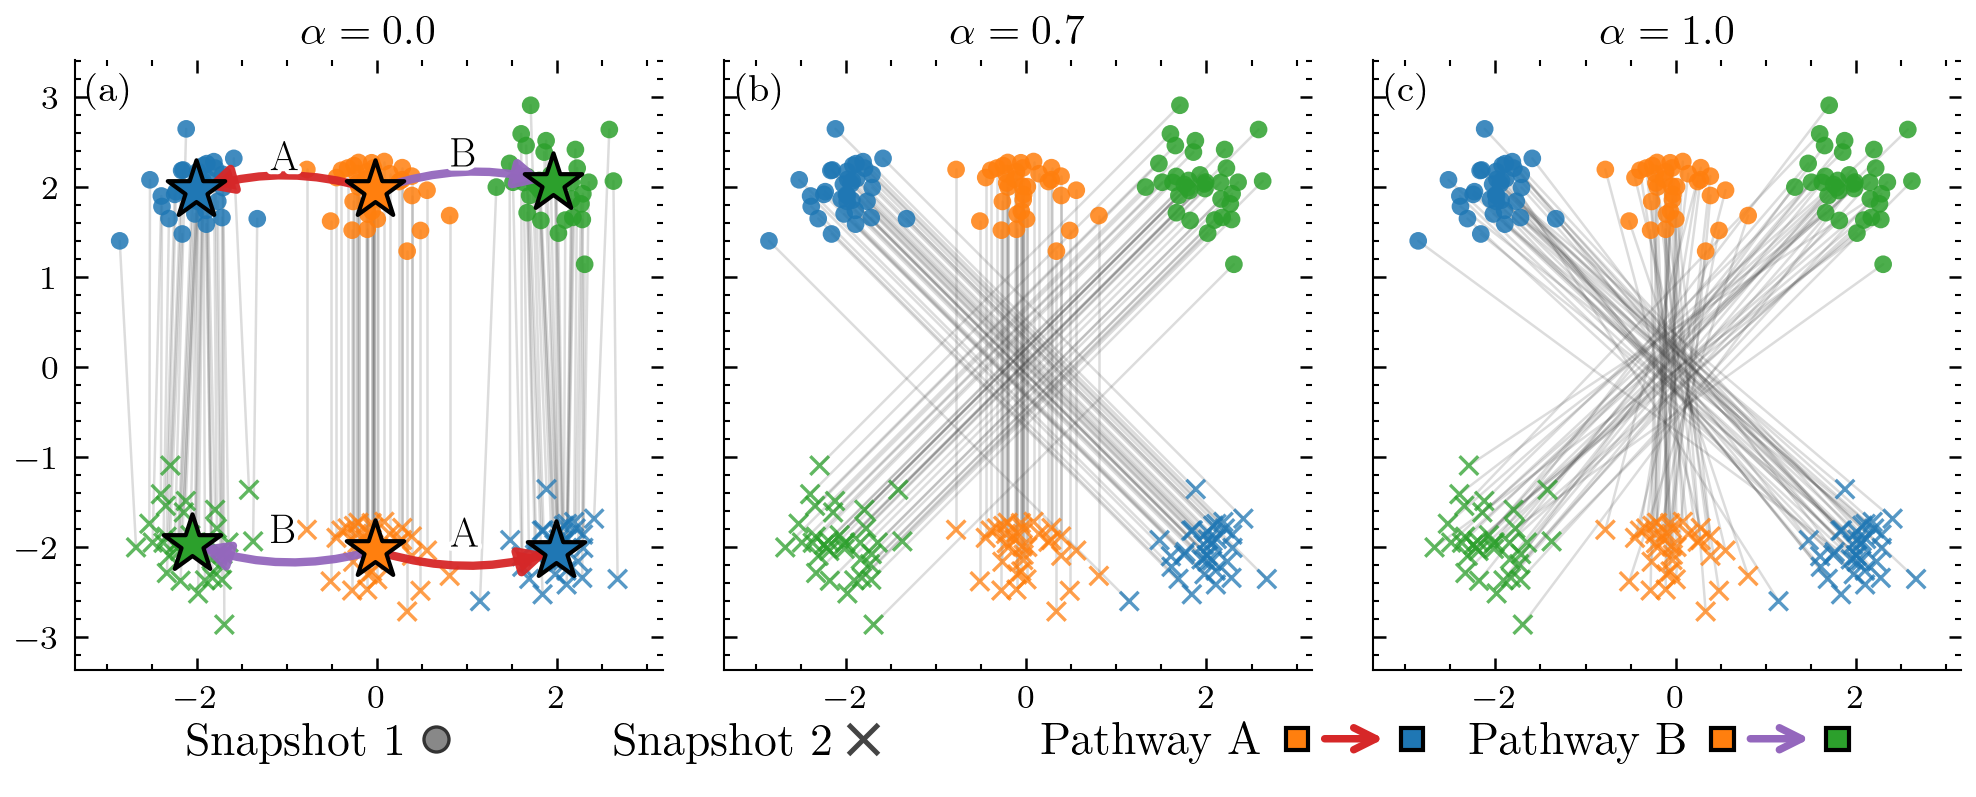

In [4]:
import matplotlib.pyplot as plt

alpha_values_to_plot = [0.0, 0.7, 1.0]

x_min, x_max = min(X1[:, 0].min(), X2[:, 0].min()), max(X1[:, 0].max(), X2[:, 0].max())
y_min, y_max = min(X1[:, 1].min(), X2[:, 1].min()), max(X1[:, 1].max(), X2[:, 1].max())
margin = 0.5

fig, axes = plot_transport_three_panels(
    alpha_values=alpha_values_to_plot,
    alphas=alphas,
    Ts=Ts,
    X1=X1,
    X2=X2,
    y1=y1,
    y2=y2,
    figsize=(7.2, 2.6),
    xlim=(x_min - margin, x_max + margin),
    ylim=(y_min - margin, y_max + margin),
    save_path="../../figures/synthetic_experiment.pdf",
)

plt.show()


